# Opiods Overdose in Shelters

This notebook analyses:
- How have suspected opioid overdoses in Toronto shelters changed over time (by year and quarter)?
- Is there an overall upward or downward trend?
- Which year had the highest number of overdoses?
- Are overdoses increasing faster in recent years?

And many more. Data was imported from Open Toronto database

## 1. Imports

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as path_effects
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
import geopandas as gpd
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## 2. Helper — Make a Choropleth Map

In [43]:
def _choropleth(gdf_plot, column, title, cbar_label, cmap, out_file=None, label_col=None):
    """
    Draw a choropleth map with an optional basemap and polygon centroid labels.

    Parameters
    ----------
    label_col : str, optional
        Column whose value is printed at each polygon's representative point.
        Pass SHP_JOIN_COL to show neighbourhood numbers.
    out_file : str, optional
        If provided, saves the figure to this path.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # Grey fill for unmatched polygons
    gdf_plot[gdf_plot[column].isna()].plot(
        ax=ax, color="#cccccc", edgecolor="white", linewidth=0.3
    )

    # Choropleth layer
    gdf_plot[gdf_plot[column].notna()].plot(
        column=column,
        ax=ax,
        cmap=cmap,
        edgecolor="white",
        linewidth=0.3,
        alpha=0.80,
        legend=True,
        legend_kwds={
            "label": cbar_label,
            "orientation": "vertical",
            "shrink": 0.6,
            "pad": 0.02,
        }
    )

    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

    # Neighbourhood number labels at representative points
    if label_col:
        label_gdf = gdf_plot[[label_col, "geometry"]].copy()
        label_gdf["_pt"] = label_gdf.geometry.representative_point()

        for _, row in label_gdf.iterrows():
            val = row[label_col]
            if pd.isna(val):
                continue
            ax.annotate(
                text=str(int(val)),
                xy=(row["_pt"].x, row["_pt"].y),
                ha="center", va="center",
                fontsize=5.5, fontweight="bold", color="black",
                path_effects=[
                    path_effects.withStroke(linewidth=2, foreground="white")
                ],
            )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=14)
    ax.set_axis_off()
    plt.tight_layout()

    if out_file:
        plt.savefig(out_file, dpi=150, bbox_inches="tight")
        print(f"  Saved: {out_file}")

    plt.show()

## 3. Data Loading

In [44]:
overdosemap_df    = pd.read_csv("soois.csv")

print(f"overdosemap_df    : {overdosemap_df.shape[0]:,} rows, {overdosemap_df.shape[1]} columns")
overdosemap_df.head(10)

overdosemap_df    : 1,963 rows, 6 columns


,_id,location_name,address,year,year_stage,suspected_non_fatal_overdoses
0,1,45 The Esplanade,45 The Esplanade,2021,Q1,5
1,2,45 The Esplanade,45 The Esplanade,2021,Q2,14
2,3,45 The Esplanade,45 The Esplanade,2021,Q3,46
3,4,45 The Esplanade,45 The Esplanade,2021,Q4,33
4,5,45 The Esplanade,45 The Esplanade,2022,Q1,22
5,6,45 The Esplanade,45 The Esplanade,2022,Q2,14
6,7,45 The Esplanade,45 The Esplanade,2022,Q3,9
7,8,45 The Esplanade,45 The Esplanade,2022,Q4,8
8,9,885 Scarborough Golf Club Road,885 Scarborough Golf Club Road,2024,Q4,< 5
9,10,Adelaide Resource Centre for Women,67 Adelaide St E,2022,Q1,< 5


## 4. Understanding Our Data 

In [45]:
overdosemap_df.columns = overdosemap_df.columns.str.lower().str.strip()
# =========================
# 4. CLEAN OVERDOSE COLUMN
# =========================
col = "suspected_non_fatal_overdoses"

# Convert to string for safe processing
overdosemap_df[col] = overdosemap_df[col].astype(str)

# Identify "<5" values
mask = overdosemap_df[col].str.contains(r"<\s*5", regex=True)

# Replace "<5" with random integers from 1 to 5
overdosemap_df.loc[mask, col] = np.random.randint(1, 6, size=mask.sum())

# Extract numeric values (in case of messy strings)
overdosemap_df[col] = (
    overdosemap_df[col]
    .str.extract(r"(\d+)")[0]   # keep only numbers
    .fillna(0)                 # handle any remaining NaN
    .astype(int)
)

# =========================
# 5. GROUP BY YEAR + ADDRESS
# =========================
overdose_by_year_address = (
    overdosemap_df
    .groupby(["year", "address"])[col]
    .sum()
    .reset_index()
)

# =========================
# 6. OUTPUT RESULT
# =========================
overdose_by_year_address




,year,address,suspected_non_fatal_overdoses
0,2018,101 Ontario St,0
1,2018,107 Jarvis St,0
2,2018,1076 Pape Ave,0
3,2018,1161 Caledonia Rd,0
4,2018,1229 Ellesmere Rd,0
...,...,...,...
508,2025,885 SCARBOROUGH GOLF CLUB RD,0
509,2025,95 WELLESLEY ST E,0
510,2025,962 BLOOR ST W,0
511,2025,973 LANSDOWNE AVE,0


## Rank of Opioid Overdoses by Address grouped by Year

In [46]:
overdose_by_year_address = overdose_by_year_address.sort_values(
    by=["year", "suspected_non_fatal_overdoses"],
    ascending=[True, False]
)

overdose_by_year_address["rank"] = (
    overdose_by_year_address
    .groupby("year")["suspected_non_fatal_overdoses"]
    .rank(method="dense", ascending=False)
)

overdose_by_year_address = overdose_by_year_address.sort_values(
    by=["year", "rank"]
)

# ✅ NEW: Separate and display by year
for year, group in overdose_by_year_address.groupby("year"):
    print(f"\n===== Year: {year} =====")
    print(group.sort_values("rank"))
    
overdose_by_year_address


===== Year: 2018 =====
    year                address  suspected_non_fatal_overdoses  rank
19  2018          339 George St                             40   1.0
10  2018      180 Princes' Blvd                             30   2.0
22  2018          354 George St                             27   3.0
30  2018  545 Lake Shore Blvd W                             19   4.0
14  2018         25 Augusta Ave                             17   5.0
11  2018      195 Princes' Blvd                             15   6.0
5   2018           129 Peter St                             11   7.0
23  2018    3576 St Clair Ave E                              6   8.0
18  2018        323 Dundas St E                              5   9.0
27  2018       4222 Kingston Rd                              0  10.0
28  2018       445 Rexdale Blvd                              0  10.0
29  2018         525 Bloor St E                              0  10.0
31  2018      552 Adelaide St W                              0  10.0
32  2018  

,year,address,suspected_non_fatal_overdoses,rank
19,2018,339 George St,40,1.0
10,2018,180 Princes' Blvd,30,2.0
22,2018,354 George St,27,3.0
30,2018,545 Lake Shore Blvd W,19,4.0
14,2018,25 Augusta Ave,17,5.0
...,...,...,...,...
508,2025,885 SCARBOROUGH GOLF CLUB RD,0,9.0
509,2025,95 WELLESLEY ST E,0,9.0
510,2025,962 BLOOR ST W,0,9.0
511,2025,973 LANSDOWNE AVE,0,9.0


## Creating a Chloropleth

In [ ]:
import matplotlib.patheffects as path_effects
from shapely.geometry import Point
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# ── 0. Load data ──────────────────────────────────────────────────────────────
overdosemap_df = pd.read_csv("soois.csv")

# ── 1. Clean overdose counts ("< 5" → 2) ─────────────────────────────────────
overdosemap_df["overdose_count"] = (
    overdosemap_df["suspected_nor"]
    .replace("< 5", "2")
    .pipe(pd.to_numeric, errors="coerce")
)

# ── 2. Geocode unique addresses ───────────────────────────────────────────────
geolocator = Nominatim(user_agent="overdose_map_toronto")
geocode    = RateLimiter(geolocator.geocode, min_delay_seconds=1)

unique_addr_df = (
    overdosemap_df[["address"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Geocoding {len(unique_addr_df)} unique addresses — this may take a few minutes...")

unique_addr_df["location"]  = unique_addr_df["address"].apply(
    lambda addr: geocode(f"{addr}, Toronto, Ontario, Canada")
)
unique_addr_df["latitude"]  = unique_addr_df["location"].apply(lambda x: x.latitude  if x else None)
unique_addr_df["longitude"] = unique_addr_df["location"].apply(lambda x: x.longitude if x else None)

# Report any failures
failed = unique_addr_df[unique_addr_df["latitude"].isna()]
if not failed.empty:
    print(f"  ⚠️  Could not geocode {len(failed)} addresses:")
    print(failed["address"].tolist())

unique_addr_df = unique_addr_df.dropna(subset=["latitude", "longitude"])

# ── 3. Build GeoDataFrame of address points ───────────────────────────────────
gdf_points = gpd.GeoDataFrame(
    unique_addr_df[["address", "latitude", "longitude"]],
    geometry=gpd.points_from_xy(unique_addr_df["longitude"], unique_addr_df["latitude"]),
    crs="EPSG:4326"
)

# ── 4. Load neighbourhood boundaries ─────────────────────────────────────────
# Download from: https://open.toronto.ca/dataset/neighbourhoods/
gdf_neighbourhoods = gpd.read_file("toronto_neighbourhoods.geojson").to_crs(epsg=4326)

# Preview the neighbourhood ID column name
print("Neighbourhood columns:", gdf_neighbourhoods.columns.tolist())
NBHD_ID_COL = "AREA_S_CD"   # ← adjust if your file uses a different column name

# ── 5. Spatial join: assign neighbourhood to each address point ───────────────
gdf_joined = gpd.sjoin(
    gdf_points,
    gdf_neighbourhoods[[NBHD_ID_COL, "geometry"]],
    how="left",
    predicate="within"
)

# Populate address_to_neighbourhood dict
address_to_neighbourhood = dict(zip(gdf_joined["address"], gdf_joined[NBHD_ID_COL]))
print(f"  Mapped {sum(v != '' for v in address_to_neighbourhood.values())} / "
      f"{len(address_to_neighbourhood)} addresses to neighbourhoods")

# ── 6. Map neighbourhood back onto overdosemap_df ────────────────────────────
overdosemap_df["neighbourhood_id"] = overdosemap_df["address"].map(address_to_neighbourhood)

unmapped = overdosemap_df["neighbourhood_id"].isna().sum()
if unmapped:
    print(f"  ⚠️  {unmapped} rows have no neighbourhood match — they will appear grey on the map")

# ── 7. Aggregate total overdoses per neighbourhood ────────────────────────────
neighbourhood_counts = (
    overdosemap_df
    .groupby("neighbourhood_id")["overdose_count"]
    .sum()
    .reset_index(name="overdose_count")
)

# ── 8. Merge counts into neighbourhood polygons ───────────────────────────────
gdf_plot = gdf_neighbourhoods.merge(
    neighbourhood_counts,
    left_on=NBHD_ID_COL,
    right_on="neighbourhood_id",
    how="left"
)

# Reproject to Web Mercator for contextily basemap
gdf_plot = gdf_plot.to_crs(epsg=3857)

# ── 9. Overdose rate vs raw count ─────────────────────────────────────────────
# If you have a population column, use rate per 1,000:
#   gdf_plot["overdose_rate"] = (gdf_plot["overdose_count"] / gdf_plot["population"]) * 1_000
#   cbar_label = "Overdoses per 1,000 residents"
# Otherwise use raw counts:
gdf_plot["overdose_rate"] = gdf_plot["overdose_count"]
cbar_label = "Total Overdose Incidents"

# ── 10. Draw choropleth ───────────────────────────────────────────────────────
_choropleth(
    gdf_plot  = gdf_plot,
    column    = "overdose_rate",
    title     = "Overdose Incidents by Neighbourhood (Toronto)",
    cbar_label= cbar_label,
    cmap      = "OrRd",
    out_file  = "overdose_rate_map.png",
    label_col = NBHD_ID_COL,
)

## Heatmap of Suspected Opioid Overdoses by Shelter and Year

In [48]:
heatmap_data = overdose_by_year_address.pivot(
    index="address",
    columns="year",
    values=col
).fillna(0)

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=False,        # set True if you want numbers
    cmap="Reds",
    linewidths=0.5
)

plt.title("Heatmap of Suspected Opioid Overdoses by Shelter and Year")
plt.xlabel("Year")
plt.ylabel("Shelter Address")

plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x1000 with 0 Axes>

## 7. Normalize Rate (calculate per capita crime, i.e. per 10,000 residents)

In [ ]:
SCALE = 10_000
merged["race_bias_per_capita"] = (merged["race_bias_count"] / merged["Total"]) * SCALE

print(f"Per-capita metric : incidents per {SCALE:,} residents")
print(f"Mean rate         : {merged['race_bias_per_capita'].mean():.4f}")
print(f"Max  rate         : {merged['race_bias_per_capita'].max():.4f}")
merged[["Neighbourhood Number", "Total", "Percent Of Minority", "race_bias_per_capita"]].head()

Per-capita metric : incidents per 10,000 residents
Mean rate         : 2.0057
Max  rate         : 19.7707


,Neighbourhood Number,Total,Percent Of Minority,race_bias_per_capita
0,1,33300,0.841892,1.501502
1,2,31345,0.892487,0.000000
2,3,9850,0.680711,0.000000
3,4,10375,0.576867,0.963855
4,5,9355,0.691074,2.137894


## 8. Identify Outliers (or High-Influence Points)

In [ ]:
Q1 = overdose_by_year_address["suspected_non_fatal_overdoses"].quantile(0.25)
Q3 = overdose_by_year_address["suspected_non_fatal_overdoses"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = overdose_by_year_address[
    (overdose_by_year_address["suspected_non_fatal_overdoses"] < lower_bound) |
    (overdose_by_year_address["suspected_non_fatal_overdoses"] > upper_bound)
]

print(outliers)

     year                address  suspected_non_fatal_overdoses
10   2018      180 Princes' Blvd                             30
11   2018      195 Princes' Blvd                             15
14   2018         25 Augusta Ave                             17
19   2018          339 George St                             40
22   2018          354 George St                             27
..    ...                    ...                            ...
409  2025           129 PETER ST                             32
411  2025      135 SHERBOURNE ST                             23
434  2025     2180 ISLINGTON AVE                             30
449  2025          339 GEORGE ST                             80
475  2025  545 LAKE SHORE BLVD W                             67

[84 rows x 3 columns]


## 9. Remove Outliers

In [ ]:
reg_df_clean = reg_df.drop(index=outlier_idx).reset_index(drop=True)

X_clean = sm.add_constant(reg_df_clean["Percent Of Minority"])
y_clean = reg_df_clean["race_bias_per_capita"]

model     = sm.OLS(y_clean, X_clean).fit()
beta0     = model.params["const"]
beta1     = model.params["Percent Of Minority"]
p_val_b1  = model.pvalues["Percent Of Minority"]
r_squared = model.rsquared
n_obs     = int(model.nobs)

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     race_bias_per_capita   R-squared:                       0.033
Model:                              OLS   Adj. R-squared:                  0.027
Method:                   Least Squares   F-statistic:                     5.257
Date:                  Mon, 16 Mar 2026   Prob (F-statistic):             0.0232
Time:                          17:42:38   Log-Likelihood:                -280.27
No. Observations:                   154   AIC:                             564.5
Df Residuals:                       152   BIC:                             570.6
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

## 10. Create Scatter Plot with Regression Line

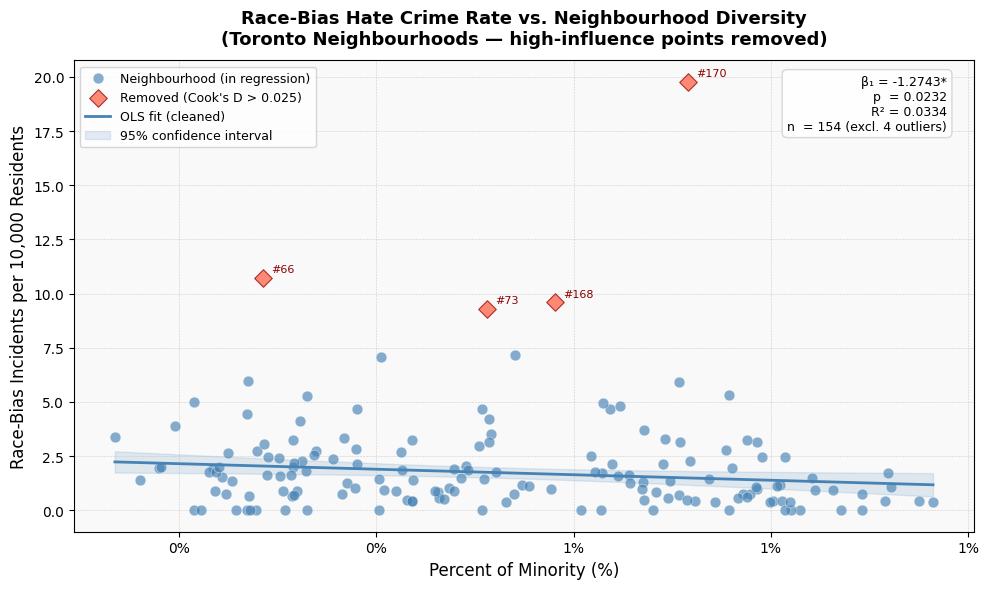

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Clean points
ax.scatter(
    reg_df_clean["Percent Of Minority"],
    reg_df_clean["race_bias_per_capita"],
    c="steelblue", alpha=0.65, edgecolors="white", linewidths=0.4,
    s=60, zorder=3, label="Neighbourhood (in regression)"
)

# Removed outliers — plotted but excluded from fit
if len(outlier_idx):
    outlier_rows = reg_df.iloc[outlier_idx]
    ax.scatter(
        outlier_rows["Percent Of Minority"],
        outlier_rows["race_bias_per_capita"],
        c="tomato", alpha=0.75, edgecolors="darkred", linewidths=0.8,
        s=80, marker="D", zorder=4,
        label=f"Removed (Cook's D > {outlier_threshold:.3f})"
    )
    for _, row in outlier_rows.iterrows():
        ax.annotate(
            f"#{int(row['Neighbourhood Number'])}",
            xy=(row["Percent Of Minority"], row["race_bias_per_capita"]),
            xytext=(6, 4), textcoords="offset points",
            fontsize=8, color="darkred"
        )

# Regression line + 95% CI
x_range = np.linspace(reg_df_clean["Percent Of Minority"].min(),
                      reg_df_clean["Percent Of Minority"].max(), 200)
pred_df = model.get_prediction(sm.add_constant(x_range)).summary_frame(alpha=0.05)

ax.plot(x_range, pred_df["mean"], color="steelblue", linewidth=2,
        zorder=5, label="OLS fit (cleaned)")
ax.fill_between(x_range, pred_df["mean_ci_lower"], pred_df["mean_ci_upper"],
                color="steelblue", alpha=0.15, label="95% confidence interval")

# Stats annotation
sig_star = "***" if p_val_b1 < 0.001 else "**" if p_val_b1 < 0.01 else "*" if p_val_b1 < 0.05 else "ns"
stats_text = (
    f"β₁ = {beta1:.4f}{sig_star}\n"
    f"p  = {p_val_b1:.4f}\n"
    f"R² = {r_squared:.4f}\n"
    f"n  = {n_obs} (excl. {len(outlier_idx)} outlier{'s' if len(outlier_idx) != 1 else ''})"
)
ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
        fontsize=9, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="lightgray", alpha=0.9))

ax.set_xlabel("Percent of Minority (%)", fontsize=12)
ax.set_ylabel(f"Race-Bias Incidents per {SCALE:,} Residents", fontsize=12)
ax.set_title(
    "Race-Bias Hate Crime Rate vs. Neighbourhood Diversity\n"
    "(Toronto Neighbourhoods — high-influence points removed)",
    fontsize=13, fontweight="bold", pad=12
)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
ax.set_facecolor("#f9f9f9")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

## 11. Summary Table

In [ ]:
summary = (
    merged[["Neighbourhood Number", "race_bias_count",
            "Total", "Percent Of Minority", "race_bias_per_capita"]]
    .sort_values("race_bias_per_capita", ascending=False)
    .head(20)
    .rename(columns={
        "Neighbourhood Number": "Hood #",
        "race_bias_count":      "Incidents",
        "Total":                "Population",
        "Percent Of Minority":  "% Minority",
        "race_bias_per_capita": "Incidents/10k"
    })
)
summary.style.format({"Population": "{:,.0f}", "% Minority": "{:.2%}", "Incidents/10k": "{:.4f}"})

,Hood #,Incidents,Population,% Minority,Incidents/10k
153,170,25.000000,"12,645",71.57%,19.7707
60,66,10.000000,"9,310",28.52%,10.7411
151,168,17.000000,"17,695",58.10%,9.6072
67,73,20.000000,"21,495",51.17%,9.3045
150,167,16.000000,"22,320",54.08%,7.1685
15,18,8.000000,"11,345",40.50%,7.0516
78,88,13.000000,"21,855",27.02%,5.9483
68,74,11.000000,"18,535",70.65%,5.9347
23,27,15.000000,"28,255",75.74%,5.3088
16,19,6.000000,"11,360",33.01%,5.2817


## 12. Load Neighborhood Shapefile & Merge

In [ ]:
gdf = gpd.read_file("data/Neighbourhoods - 4326.shp")

print(f"CRS       : {gdf.crs}")
print(f"Rows      : {len(gdf)}")
print(f"Columns   : {list(gdf.columns)}")

CRS       : EPSG:4326
Rows      : 158
Columns   : ['_id1', 'AREA_ID2', 'AREA_AT3', 'PARENT_4', 'AREA_SH5', 'AREA_LO6', 'AREA_NA7', 'AREA_DE8', 'CLASSIF9', 'CLASSIF10', 'OBJECTI11', 'geometry']


In [ ]:
SHP_JOIN_COL = "AREA_SH5"   # ← update if your shapefile uses a different column

gdf[SHP_JOIN_COL] = pd.to_numeric(gdf[SHP_JOIN_COL], errors="coerce")

# Reproject to Web Mercator (required by contextily)
gdf = gdf.to_crs(epsg=3857)

plot_gdf = gdf.merge(
    merged[["Neighbourhood Number", "Percent Of Minority", "race_bias_per_capita"]],
    left_on=SHP_JOIN_COL,
    right_on="Neighbourhood Number",
    how="left"
)

missing = plot_gdf["Percent Of Minority"].isna().sum()
if missing:
    print(f"⚠ {missing} polygon(s) had no match in merged data — will appear grey.")
else:
    print("✓ All polygons matched successfully.")

✓ All polygons matched successfully.


## 13. Choropleth of Visible Minority % (Diversity)

  Saved: choropleth_diversity.png


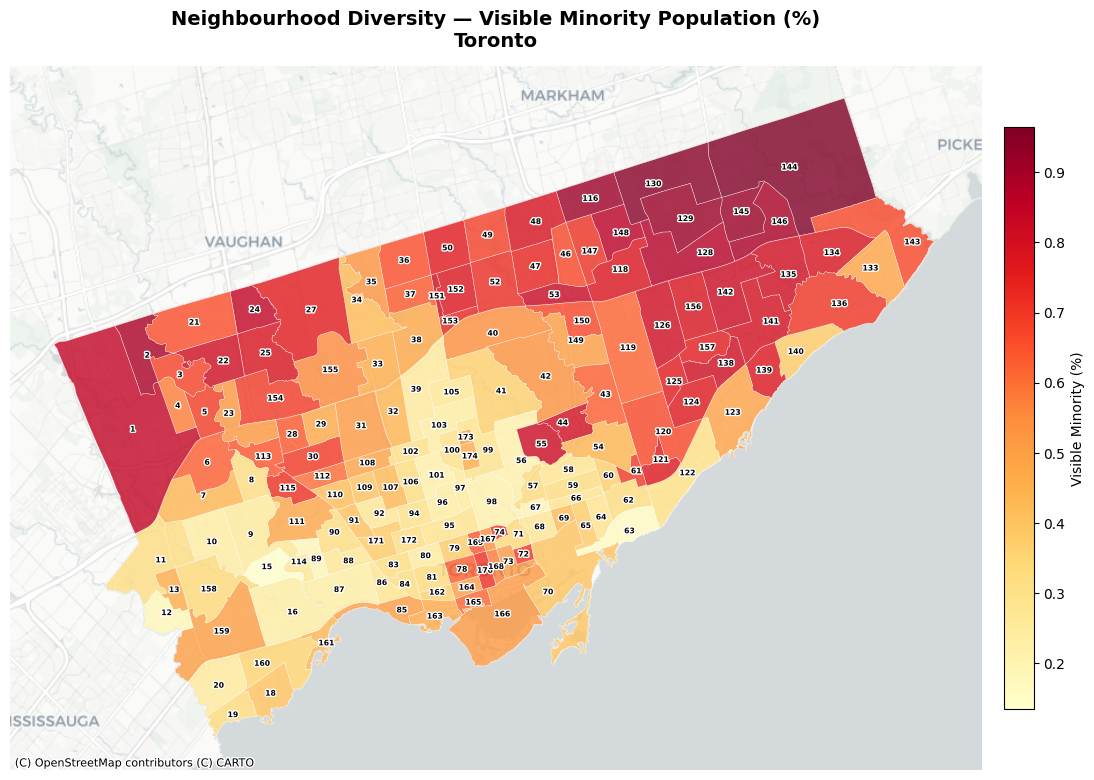

In [ ]:
_choropleth(
    gdf_plot  = plot_gdf,
    column    = "Percent Of Minority",
    title     = "Neighbourhood Diversity — Visible Minority Population (%)\nToronto",
    cbar_label= "Visible Minority (%)",
    cmap      = "YlOrRd",
    out_file  = "choropleth_diversity.png",
    label_col = SHP_JOIN_COL,
)

## 14.Choropleth of Race-Bias Incidents per 10,000 Residents in the TPS database

  Saved: choropleth_race_bias_per_capita.png


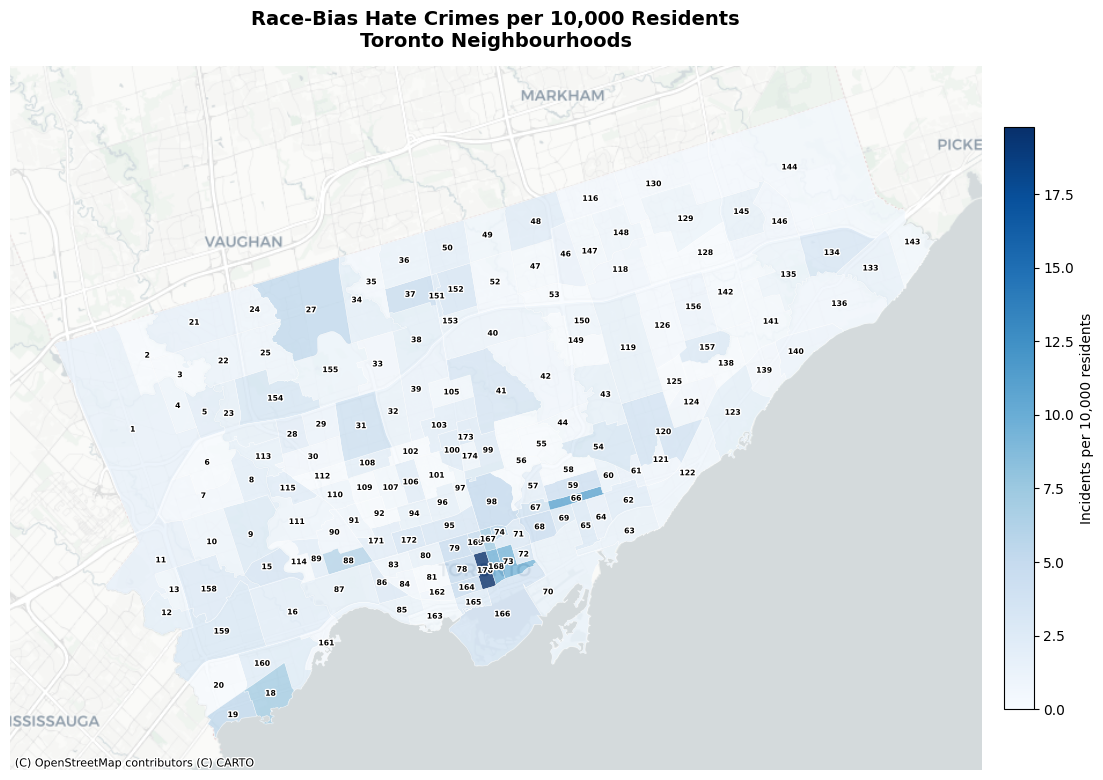

In [ ]:
_choropleth(
    gdf_plot  = plot_gdf,
    column    = "race_bias_per_capita",
    title     = f"Race-Bias Hate Crimes per {SCALE:,} Residents\nToronto Neighbourhoods",
    cbar_label= f"Incidents per {SCALE:,} residents",
    cmap      = "Blues",
    out_file  = "choropleth_race_bias_per_capita.png",
    label_col = SHP_JOIN_COL,
)